In [10]:
import pandas as pd

fund_master = pd.read_csv("../data/processed/01_fund_master.csv")
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
aum = pd.read_csv("../data/processed/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/processed/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/processed/05_category_inflows.csv")
folios = pd.read_csv("../data/processed/06_industry_folio_count.csv")
performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")
transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")
holdings = pd.read_csv("../data/processed/09_portfolio_holdimgs.csv")

for name, df in {
    "aum": aum,
    "sip": sip,
    "category": category,
    "folios": folios,
    "holdings": holdings
}.items():
    print("\n", name.upper())
    print(df.columns.tolist())
    


 AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

 SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

 CATEGORY
['month', 'category', 'net_inflow_crore']

 FOLIOS
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

 HOLDINGS
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


C:\Users\sanje\AppData\Local\Temp\ipykernel_5240\2553366826.py:5: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  aum["year"] = pd.to_datetime(aum["date"]).dt.year


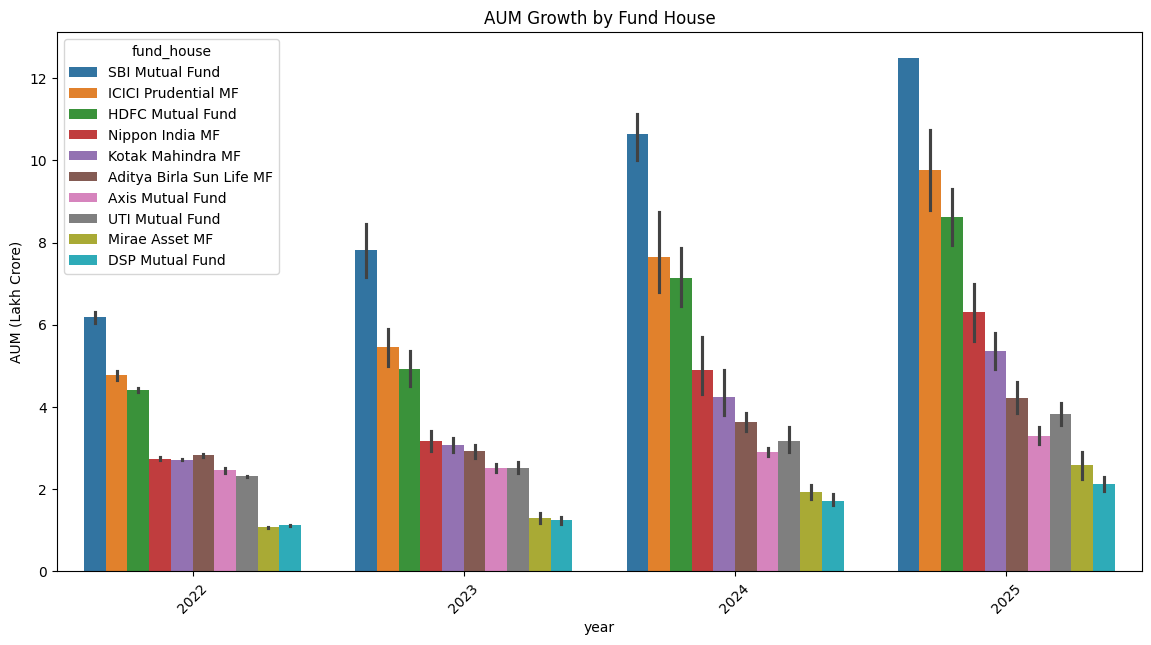

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aum["year"] = pd.to_datetime(aum["date"]).dt.year

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)

plt.savefig("../reports/charts/aum_growth.png")
plt.show()

In [33]:
import plotly.express as px

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

peak_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=peak_row["month"],
    y=peak_row["sip_inflow_crore"],
    text=f"₹{peak_row['sip_inflow_crore']:,.0f} Cr High"
)



plt.savefig("../reports/charts/aum_growth2.png")
fig.show()

<Figure size 640x480 with 0 Axes>

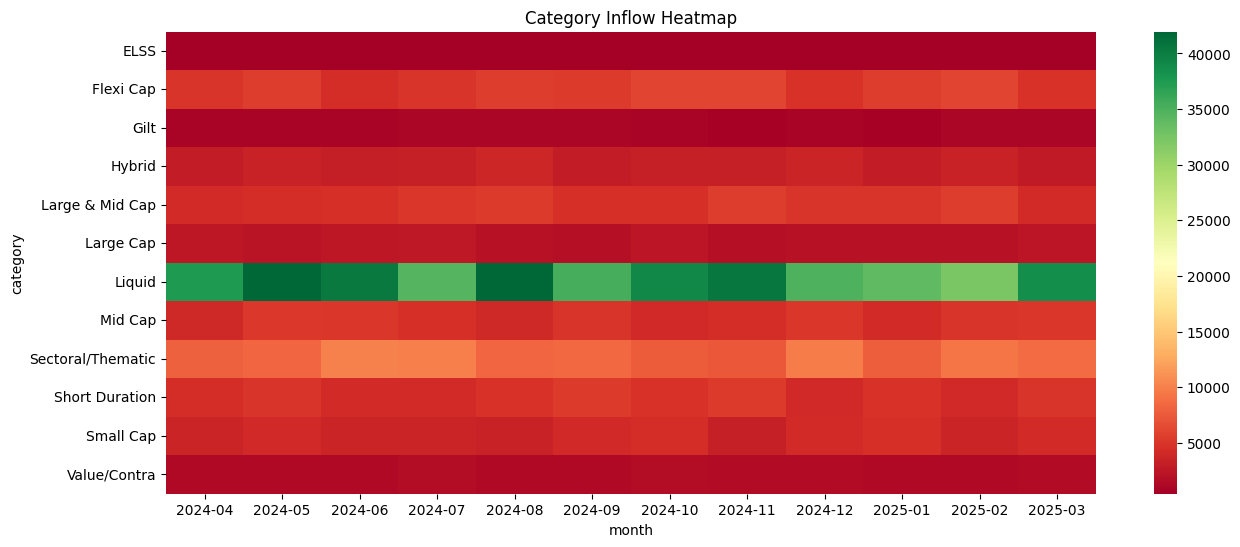

In [14]:
pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))

sns.heatmap(
    pivot,
    cmap="RdYlGn"
)

plt.title("Category Inflow Heatmap")

plt.savefig("../reports/charts/category_heatmap.png")
plt.show()

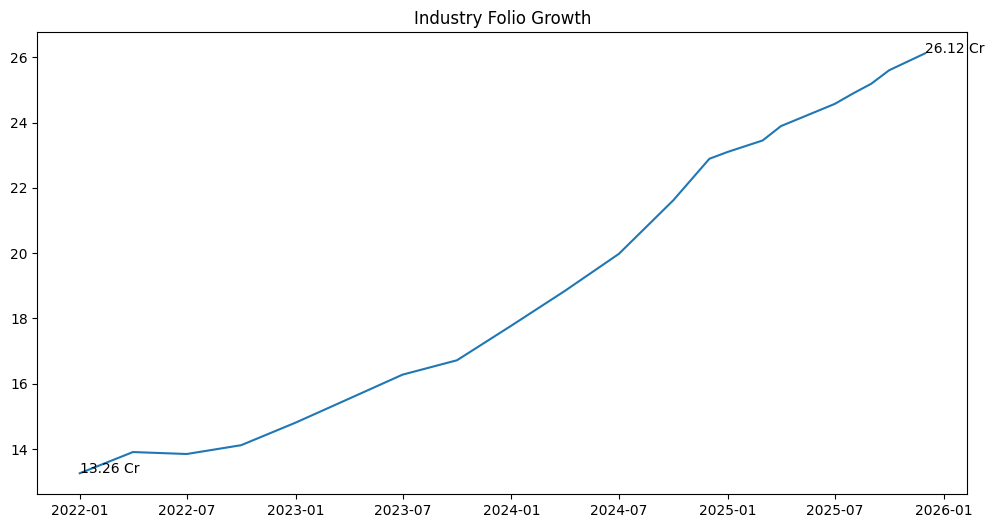

In [15]:
folios["month"] = pd.to_datetime(folios["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.annotate(
    "13.26 Cr",
    xy=(folios.iloc[0]["month"],
        folios.iloc[0]["total_folios_crore"])
)

plt.annotate(
    "26.12 Cr",
    xy=(folios.iloc[-1]["month"],
        folios.iloc[-1]["total_folios_crore"])
)

plt.savefig("../reports/charts/folio_growth.png")

plt.show()

In [34]:
import plotly.express as px

sector = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sector,
    values="weight_pct",
    names="sector",
    hole=0.5,
    title="Sector Allocation"
)

fig.show()

plt.savefig("../reports/charts/sector allocation.png")
fig.show()

<Figure size 640x480 with 0 Axes>

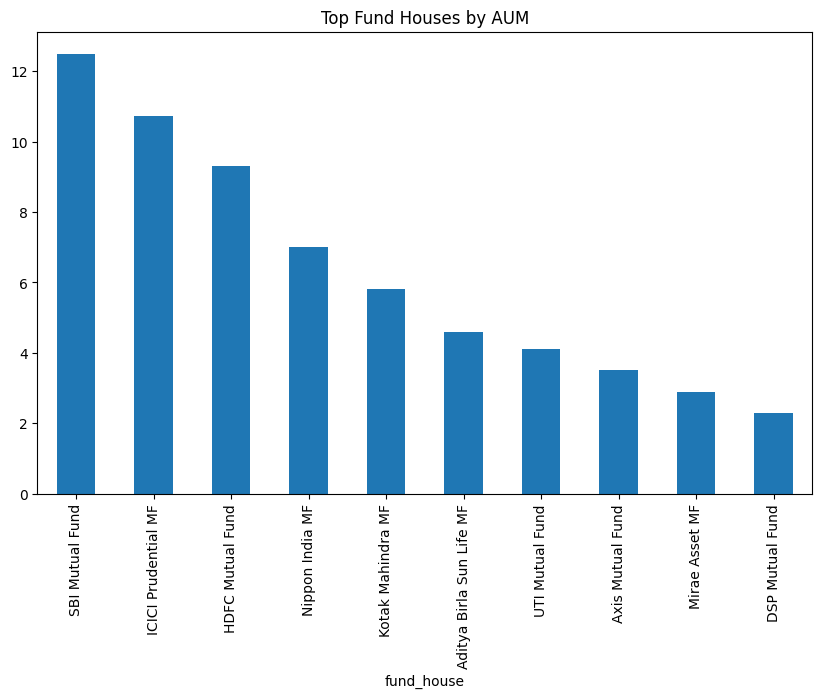

In [18]:
top_aum = (
    aum.groupby("fund_house")["aum_lakh_crore"]
    .max()
    .sort_values(ascending=False)
)

top_aum.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top Fund Houses by AUM")

plt.savefig(
    "../reports/charts/top_fund_houses.png"
)

plt.show()

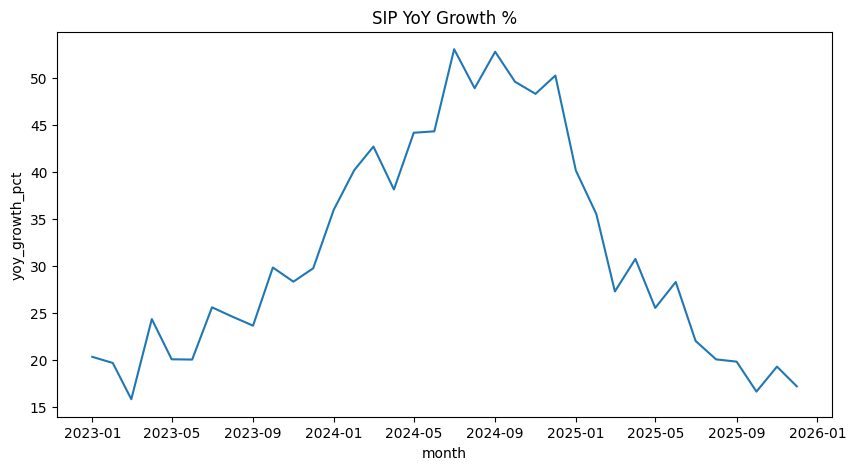

In [19]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=sip,
    x="month",
    y="yoy_growth_pct"
)

plt.title("SIP YoY Growth %")

plt.savefig(
    "../reports/charts/sip_yoy_growth.png"
)

plt.show()

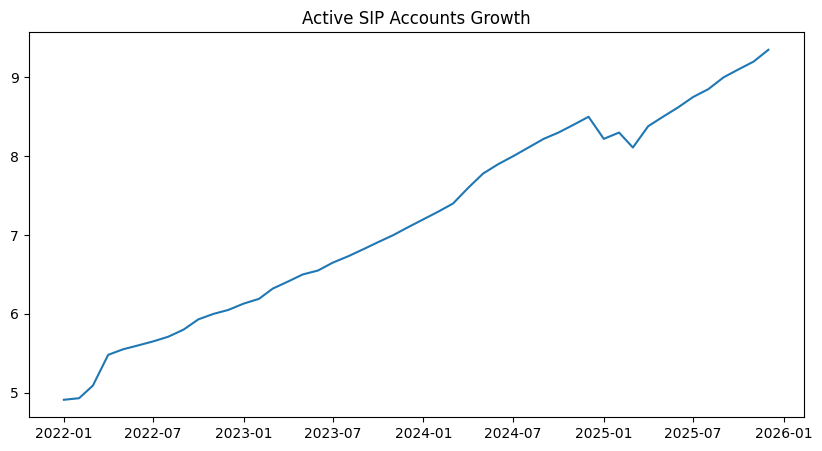

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    pd.to_datetime(sip["month"]),
    sip["active_sip_accounts_crore"]
)

plt.title("Active SIP Accounts Growth")

plt.savefig(
    "../reports/charts/active_sip_accounts.png"
)

plt.show()

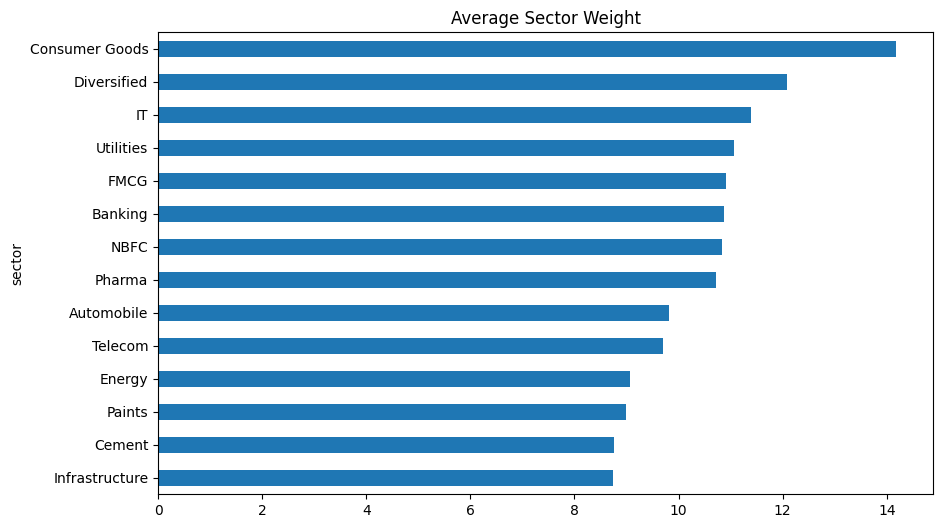

In [21]:
sector_avg = (
    holdings.groupby("sector")["weight_pct"]
    .mean()
    .sort_values()
)

sector_avg.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Average Sector Weight")

plt.savefig(
    "../reports/charts/avg_sector_weight.png"
)

plt.show()